In [1]:
from torchvision import transforms as T
from matplotlib import pyplot as plt
from PIL import Image
from __future__ import annotations
import numpy as np

import math
from scheduler import Scheduler

from collections.abc import Callable
from functools import partial
from monai_model import DDPMPL

import torch
import torch.nn as nn
import torch.nn.functional as F
from monai.inferers import Inferer
from monai.utils import optional_import, StrEnum
from collections import OrderedDict

from generative.networks.nets import SPADEDiffusionModelUNet

tqdm, has_tqdm = optional_import("tqdm", name="tqdm")
device = torch.device("cuda")


(-0.5, 255.5, 255.5, -0.5)

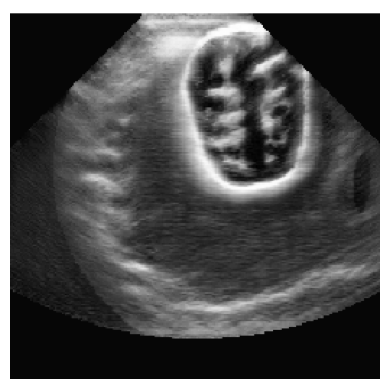

In [7]:
transform = T.Compose([T.Pad((0, 80, 0, 0)), T.CenterCrop(256)])
image = Image.open("/mnt/raid/home/ajarry/data/newplot.png").convert("RGB")
image = transform(image)
plt.imshow(image)
plt.axis('off')


SCHEDULER

In [3]:
class DDPMVarianceType(StrEnum):
    """
    Valid names for DDPM Scheduler's `variance_type` argument. Options to clip the variance used when adding noise
    to the denoised sample.
    """

    FIXED_SMALL = "fixed_small"
    FIXED_LARGE = "fixed_large"
    LEARNED = "learned"
    LEARNED_RANGE = "learned_range"


class DDPMPredictionType(StrEnum):
    """
    Set of valid prediction type names for the DDPM scheduler's `prediction_type` argument.

    epsilon: predicting the noise of the diffusion process
    sample: directly predicting the noisy sample
    v_prediction: velocity prediction, see section 2.4 https://imagen.research.google/video/paper.pdf
    """

    EPSILON = "epsilon"
    SAMPLE = "sample"
    V_PREDICTION = "v_prediction"


class DDPMScheduler2(Scheduler):
    """
    Denoising diffusion probabilistic models (DDPMs) explores the connections between denoising score matching and
    Langevin dynamics sampling. Based on: Ho et al., "Denoising Diffusion Probabilistic Models"
    https://arxiv.org/abs/2006.11239

    Args:
        num_train_timesteps: number of diffusion steps used to train the model.
        schedule: member of NoiseSchedules, name of noise schedule function in component store
        variance_type: member of DDPMVarianceType
        clip_sample: option to clip predicted sample between -1 and 1 for numerical stability.
        prediction_type: member of DDPMPredictionType
        clip_sample_min: minimum clipping value when clip_sample equals True
        clip_sample_max: maximum clipping value when clip_sample equals True
        schedule_args: arguments to pass to the schedule function
    """

    def __init__(
        self,
        num_train_timesteps: int = 15,
        schedule: str = "linear_beta",
        variance_type: str = DDPMVarianceType.FIXED_SMALL,
        clip_sample: bool = True,
        prediction_type: str = DDPMPredictionType.EPSILON,
        clip_sample_min: float = -1.0,
        clip_sample_max: float = 1.0,
        **schedule_args,
    ) -> None:
        super().__init__(num_train_timesteps, schedule, **schedule_args)

        if variance_type not in DDPMVarianceType.__members__.values():
            raise ValueError("Argument `variance_type` must be a member of `DDPMVarianceType`")

        if prediction_type not in DDPMPredictionType.__members__.values():
            raise ValueError("Argument `prediction_type` must be a member of `DDPMPredictionType`")

        self.clip_sample = clip_sample
        self.clip_sample_values = [clip_sample_min, clip_sample_max]
        self.variance_type = variance_type
        self.prediction_type = prediction_type

    def set_timesteps(self, num_inference_steps: int, device: str | torch.device | None = None) -> None:
        """
        Sets the discrete timesteps used for the diffusion chain. Supporting function to be run before inference.

        Args:
            num_inference_steps: number of diffusion steps used when generating samples with a pre-trained model.
            device: target device to put the data.
        """
        if num_inference_steps > self.num_train_timesteps:
            raise ValueError(
                f"`num_inference_steps`: {num_inference_steps} cannot be larger than `self.num_train_timesteps`:"
                f" {self.num_train_timesteps} as the unet model trained with this scheduler can only handle"
                f" maximal {self.num_train_timesteps} timesteps."
            )

        self.num_inference_steps = num_inference_steps
        print("self.num_inference_steps", self.num_inference_steps)
        print("self.num_train_timesteps", self.num_train_timesteps)

        step_ratio = math.ceil(self.num_train_timesteps / self.num_inference_steps)
        # creates integer timesteps by multiplying by ratio
        # casting to int to avoid issues when num_inference_step is power of 3
        timesteps = (np.arange(0, num_inference_steps) * step_ratio).round()[::-1].astype(np.int64)
        self.timesteps = torch.from_numpy(timesteps).to(device)

    def _get_mean(self, timestep: int, x_0: torch.Tensor, x_t: torch.Tensor) -> torch.Tensor:
        """
        Compute the mean of the posterior at timestep t.

        Args:
            timestep: current timestep.
            x0: the noise-free input.
            x_t: the input noised to timestep t.

        Returns:
            Returns the mean
        """
        # these attributes are used for calculating the posterior, q(x_{t-1}|x_t,x_0),
        # (see formula (5-7) from https://arxiv.org/pdf/2006.11239.pdf)
        alpha_t = self.alphas[timestep]
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[timestep - 1] if timestep > 0 else self.one

        x_0_coefficient = alpha_prod_t_prev.sqrt() * self.betas[timestep] / (1 - alpha_prod_t)
        x_t_coefficient = alpha_t.sqrt() * (1 - alpha_prod_t_prev) / (1 - alpha_prod_t)

        mean: torch.Tensor = x_0_coefficient * x_0 + x_t_coefficient * x_t

        return mean

    def _get_variance(self, timestep: int, predicted_variance: torch.Tensor | None = None) -> torch.Tensor:
        """
        Compute the variance of the posterior at timestep t.

        Args:
            timestep: current timestep.
            predicted_variance: variance predicted by the model.

        Returns:
            Returns the variance
        """
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[timestep - 1] if timestep > 0 else self.one

        # For t > 0, compute predicted variance βt (see formula (6) and (7) from https://arxiv.org/pdf/2006.11239.pdf)
        # and sample from it to get previous sample
        # x_{t-1} ~ N(pred_prev_sample, variance) == add variance to pred_sample
        variance: torch.Tensor = (1 - alpha_prod_t_prev) / (1 - alpha_prod_t) * self.betas[timestep]
        # hacks - were probably added for training stability
        if self.variance_type == DDPMVarianceType.FIXED_SMALL:
            variance = torch.clamp(variance, min=1e-20)
        elif self.variance_type == DDPMVarianceType.FIXED_LARGE:
            variance = self.betas[timestep]
        elif self.variance_type == DDPMVarianceType.LEARNED and predicted_variance is not None:
            return predicted_variance
        elif self.variance_type == DDPMVarianceType.LEARNED_RANGE and predicted_variance is not None:
            min_log = variance
            max_log = self.betas[timestep]
            frac = (predicted_variance + 1) / 2
            variance = frac * max_log + (1 - frac) * min_log

        return variance

    def step(
        self, model_output: torch.Tensor, timestep: int, sample: torch.Tensor, generator: torch.Generator | None = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Predict the sample at the previous timestep by reversing the SDE. Core function to propagate the diffusion
        process from the learned model outputs (most often the predicted noise).

        Args:
            model_output: direct output from learned diffusion model.
            timestep: current discrete timestep in the diffusion chain.
            sample: current instance of sample being created by diffusion process.
            generator: random number generator.

        Returns:
            pred_prev_sample: Predicted previous sample
        """
        if model_output.shape[1] == sample.shape[1] * 2 and self.variance_type in ["learned", "learned_range"]:
            model_output, predicted_variance = torch.split(model_output, sample.shape[1], dim=1)
        else:
            predicted_variance = None

        # 1. compute alphas, betas
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[timestep - 1] if timestep > 0 else self.one
        beta_prod_t = 1 - alpha_prod_t
        beta_prod_t_prev = 1 - alpha_prod_t_prev

        # 2. compute predicted original sample from predicted noise also called
        # "predicted x_0" of formula (15) from https://arxiv.org/pdf/2006.11239.pdf
        if self.prediction_type == DDPMPredictionType.EPSILON:
            pred_original_sample = (sample - beta_prod_t ** (0.5) * model_output) / alpha_prod_t ** (0.5)
        elif self.prediction_type == DDPMPredictionType.SAMPLE:
            pred_original_sample = model_output
        elif self.prediction_type == DDPMPredictionType.V_PREDICTION:
            pred_original_sample = (alpha_prod_t**0.5) * sample - (beta_prod_t**0.5) * model_output

        # 3. Clip "predicted x_0"
        if self.clip_sample:
            pred_original_sample = torch.clamp(
                pred_original_sample, self.clip_sample_values[0], self.clip_sample_values[1]
            )

        # 4. Compute coefficients for pred_original_sample x_0 and current sample x_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_original_sample_coeff = (alpha_prod_t_prev ** (0.5) * self.betas[timestep]) / beta_prod_t
        current_sample_coeff = self.alphas[timestep] ** (0.5) * beta_prod_t_prev / beta_prod_t

        # 5. Compute predicted previous sample µ_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_prev_sample = pred_original_sample_coeff * pred_original_sample + current_sample_coeff * sample

        # 6. Add noise
        variance = 0
        if timestep > 0:
            noise = torch.randn(
                model_output.size(),
                dtype=model_output.dtype,
                layout=model_output.layout,
                generator=generator,
                device=model_output.device,
            )
            variance = (self._get_variance(timestep, predicted_variance=predicted_variance) ** 0.5) * noise

        pred_prev_sample = pred_prev_sample + variance

        return pred_prev_sample, pred_original_sample


INFERENCE

In [4]:
class DiffusionInferer(Inferer):
    """
    DiffusionInferer takes a trained diffusion model and a scheduler and can be used to perform a signal forward pass
    for a training iteration, and sample from the model.

    Args:
        scheduler: diffusion scheduler.
    """

    def __init__(self, scheduler: nn.Module) -> None:
        Inferer.__init__(self)
        self.scheduler = scheduler

    def __call__(
        self,
        inputs: torch.Tensor,
        diffusion_model: Callable[..., torch.Tensor],
        noise: torch.Tensor,
        timesteps: torch.Tensor,
        condition: torch.Tensor | None = None,
        mode: str = "crossattn",
        seg: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Implements the forward pass for a supervised training iteration.

        Args:
            inputs: Input image to which noise is added.
            diffusion_model: diffusion model.
            noise: random noise, of the same shape as the input.
            timesteps: random timesteps.
            condition: Conditioning for network input.
            mode: Conditioning mode for the network.
            seg: if model is instance of SPADEDiffusionModelUnet, segmentation must be
            provided on the forward (for SPADE-like AE or SPADE-like DM)
        """
        if mode not in ["crossattn", "concat"]:
            raise NotImplementedError(f"{mode} condition is not supported")

        noisy_image = self.scheduler.add_noise(original_samples=inputs, noise=noise, timesteps=timesteps)
        if mode == "concat":
            noisy_image = torch.cat([noisy_image, condition], dim=1)
            condition = None
        diffusion_model = (
            partial(diffusion_model, seg=seg)
            if isinstance(diffusion_model, SPADEDiffusionModelUNet)
            else diffusion_model
        )
        prediction = diffusion_model(x=noisy_image, timesteps=timesteps, context=condition)

        return prediction

    @torch.no_grad()
    def sample(
        self,
        input_noise: torch.Tensor,
        diffusion_model: Callable[..., torch.Tensor],
        scheduler: Callable[..., torch.Tensor] | None = None,
        save_intermediates: bool | None = False,
        intermediate_steps: int | None = 100,
        conditioning: torch.Tensor | None = None,
        mode: str = "crossattn",
        verbose: bool = True,
        seg: torch.Tensor | None = None,
    ) -> torch.Tensor | tuple[torch.Tensor, list[torch.Tensor]]:
        """
        Args:
            input_noise: random noise, of the same shape as the desired sample.
            diffusion_model: model to sample from.
            scheduler: diffusion scheduler. If none provided will use the class attribute scheduler
            save_intermediates: whether to return intermediates along the sampling change
            intermediate_steps: if save_intermediates is True, saves every n steps
            conditioning: Conditioning for network input.
            mode: Conditioning mode for the network.
            verbose: if true, prints the progression bar of the sampling process.
            seg: if diffusion model is instance of SPADEDiffusionModel, segmentation must be provided.
        """
        if mode not in ["crossattn", "concat"]:
            raise NotImplementedError(f"{mode} condition is not supported")

        if not scheduler:
            scheduler = self.scheduler
        image = input_noise
        if verbose and has_tqdm:
            progress_bar = tqdm([t+1 for t in scheduler.timesteps])
        else:
            progress_bar = iter([t+1 for t in scheduler.timesteps])
        intermediates = []
        for idx, t in enumerate(progress_bar):
            original_t = scheduler.timesteps[idx]

            # 1. predict noise model_output
            diffusion_model = (
                partial(diffusion_model, seg=seg)
                if isinstance(diffusion_model, SPADEDiffusionModelUNet)
                else diffusion_model
            )
            if mode == "concat":
                model_input = torch.cat([image, conditioning], dim=1)
                model_output = diffusion_model(
                    model_input, timesteps=torch.Tensor((original_t,)).to(input_noise.device), context=None
                )
            else:
                model_output = diffusion_model(
                    image, timesteps=torch.Tensor((original_t,)).to(input_noise.device), context=conditioning
                )

            # 2. compute previous image: x_t -> x_t-1
            image, _ = scheduler.step(model_output, original_t, image)
            if save_intermediates and t % intermediate_steps == 0:
                intermediates.append(image)
        if save_intermediates:
            return image, intermediates
        else:
            return image
        
        


    @torch.no_grad()
    def get_likelihood(
        self,
        inputs: torch.Tensor,
        diffusion_model: Callable[..., torch.Tensor],
        scheduler: Callable[..., torch.Tensor] | None = None,
        save_intermediates: bool | None = False,
        conditioning: torch.Tensor | None = None,
        mode: str = "crossattn",
        original_input_range: tuple | None = (0, 255),
        scaled_input_range: tuple | None = (0, 1),
        verbose: bool = True,
        seg: torch.Tensor | None = None,
    ) -> torch.Tensor | tuple[torch.Tensor, list[torch.Tensor]]:
        """
        Computes the log-likelihoods for an input.

        Args:
            inputs: input images, NxCxHxW[xD]
            diffusion_model: model to compute likelihood from
            scheduler: diffusion scheduler. If none provided will use the class attribute scheduler.
            save_intermediates: save the intermediate spatial KL maps
            conditioning: Conditioning for network input.
            mode: Conditioning mode for the network.
            original_input_range: the [min,max] intensity range of the input data before any scaling was applied.
            scaled_input_range: the [min,max] intensity range of the input data after scaling.
            verbose: if true, prints the progression bar of the sampling process.
            seg: if diffusion model is instance of SPADEDiffusionModel, segmentation must be provided.
        """

        if not scheduler:
            scheduler = self.scheduler
        if scheduler._get_name() != "DDPMScheduler":
            raise NotImplementedError(
                f"Likelihood computation is only compatible with DDPMScheduler,"
                f" you are using {scheduler._get_name()}"
            )
        if mode not in ["crossattn", "concat"]:
            raise NotImplementedError(f"{mode} condition is not supported")
        if verbose and has_tqdm:
            progress_bar = tqdm(scheduler.timesteps)
        else:
            progress_bar = iter(scheduler.timesteps)
        intermediates = []
        noise = torch.randn_like(inputs).to(inputs.device)
        total_kl = torch.zeros(inputs.shape[0]).to(inputs.device)
        for t in progress_bar:
            timesteps = torch.full(inputs.shape[:1], t, device=inputs.device).long()
            noisy_image = self.scheduler.add_noise(original_samples=inputs, noise=noise, timesteps=timesteps)
            diffusion_model = (
                partial(diffusion_model, seg=seg)
                if isinstance(diffusion_model, SPADEDiffusionModelUNet)
                else diffusion_model
            )
            if mode == "concat":
                noisy_image = torch.cat([noisy_image, conditioning], dim=1)
                model_output = diffusion_model(noisy_image, timesteps=timesteps, context=None)
            else:
                model_output = diffusion_model(x=noisy_image, timesteps=timesteps, context=conditioning)

            # get the model's predicted mean,  and variance if it is predicted
            if model_output.shape[1] == inputs.shape[1] * 2 and scheduler.variance_type in ["learned", "learned_range"]:
                model_output, predicted_variance = torch.split(model_output, inputs.shape[1], dim=1)
            else:
                predicted_variance = None

            # 1. compute alphas, betas
            alpha_prod_t = scheduler.alphas_cumprod[t]
            alpha_prod_t_prev = scheduler.alphas_cumprod[t - 1] if t > 0 else scheduler.one
            beta_prod_t = 1 - alpha_prod_t
            beta_prod_t_prev = 1 - alpha_prod_t_prev

            # 2. compute predicted original sample from predicted noise also called
            # "predicted x_0" of formula (15) from https://arxiv.org/pdf/2006.11239.pdf
            if scheduler.prediction_type == "epsilon":
                pred_original_sample = (noisy_image - beta_prod_t ** (0.5) * model_output) / alpha_prod_t ** (0.5)
            elif scheduler.prediction_type == "sample":
                pred_original_sample = model_output
            elif scheduler.prediction_type == "v_prediction":
                pred_original_sample = (alpha_prod_t**0.5) * noisy_image - (beta_prod_t**0.5) * model_output
            # 3. Clip "predicted x_0"
            if scheduler.clip_sample:
                pred_original_sample = torch.clamp(pred_original_sample, -1, 1)

            # 4. Compute coefficients for pred_original_sample x_0 and current sample x_t
            # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
            pred_original_sample_coeff = (alpha_prod_t_prev ** (0.5) * scheduler.betas[t]) / beta_prod_t
            current_sample_coeff = scheduler.alphas[t] ** (0.5) * beta_prod_t_prev / beta_prod_t

            # 5. Compute predicted previous sample µ_t
            # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
            predicted_mean = pred_original_sample_coeff * pred_original_sample + current_sample_coeff * noisy_image

            # get the posterior mean and variance
            posterior_mean = scheduler._get_mean(timestep=t, x_0=inputs, x_t=noisy_image)
            posterior_variance = scheduler._get_variance(timestep=t, predicted_variance=predicted_variance)

            log_posterior_variance = torch.log(posterior_variance)
            log_predicted_variance = torch.log(predicted_variance) if predicted_variance else log_posterior_variance

            if t == 0:
                # compute -log p(x_0|x_1)
                kl = -self._get_decoder_log_likelihood(
                    inputs=inputs,
                    means=predicted_mean,
                    log_scales=0.5 * log_predicted_variance,
                    original_input_range=original_input_range,
                    scaled_input_range=scaled_input_range,
                )
            else:
                # compute kl between two normals
                kl = 0.5 * (
                    -1.0
                    + log_predicted_variance
                    - log_posterior_variance
                    + torch.exp(log_posterior_variance - log_predicted_variance)
                    + ((posterior_mean - predicted_mean) ** 2) * torch.exp(-log_predicted_variance)
                )
            total_kl += kl.view(kl.shape[0], -1).mean(axis=1)
            if save_intermediates:
                intermediates.append(kl.cpu())

        if save_intermediates:
            return total_kl, intermediates
        else:
            return total_kl

    def _approx_standard_normal_cdf(self, x):
        """
        A fast approximation of the cumulative distribution function of the
        standard normal. Code adapted from https://github.com/openai/improved-diffusion.
        """

        return 0.5 * (
            1.0 + torch.tanh(torch.sqrt(torch.Tensor([2.0 / math.pi]).to(x.device)) * (x + 0.044715 * torch.pow(x, 3)))
        )

    def _get_decoder_log_likelihood(
        self,
        inputs: torch.Tensor,
        means: torch.Tensor,
        log_scales: torch.Tensor,
        original_input_range: tuple | None = (0, 255),
        scaled_input_range: tuple | None = (0, 1),
    ) -> torch.Tensor:
        """
        Compute the log-likelihood of a Gaussian distribution discretizing to a
        given image. Code adapted from https://github.com/openai/improved-diffusion.

        Args:
            input: the target images. It is assumed that this was uint8 values,
                      rescaled to the range [-1, 1].
            means: the Gaussian mean Tensor.
            log_scales: the Gaussian log stddev Tensor.
            original_input_range: the [min,max] intensity range of the input data before any scaling was applied.
            scaled_input_range: the [min,max] intensity range of the input data after scaling.
        """
        assert inputs.shape == means.shape
        bin_width = (scaled_input_range[1] - scaled_input_range[0]) / (
            original_input_range[1] - original_input_range[0]
        )
        centered_x = inputs - means
        inv_stdv = torch.exp(-log_scales)
        plus_in = inv_stdv * (centered_x + bin_width / 2)
        cdf_plus = self._approx_standard_normal_cdf(plus_in)
        min_in = inv_stdv * (centered_x - bin_width / 2)
        cdf_min = self._approx_standard_normal_cdf(min_in)
        log_cdf_plus = torch.log(cdf_plus.clamp(min=1e-12))
        log_one_minus_cdf_min = torch.log((1.0 - cdf_min).clamp(min=1e-12))
        cdf_delta = cdf_plus - cdf_min
        log_probs = torch.where(
            inputs < -0.999,
            log_cdf_plus,
            torch.where(inputs > 0.999, log_one_minus_cdf_min, torch.log(cdf_delta.clamp(min=1e-12))),
        )
        assert log_probs.shape == inputs.shape
        return log_probs

In [5]:
scheduler = DDPMScheduler2()
inferer = DiffusionInferer(scheduler=scheduler)

hparams = {
    'lr': 2e-4,
    'weight_decay': 1e-5,
    'num_train_timesteps': 1000,
    'in_channels': 3,
    'out_channels': 3,
    'use_pre_trained': False
}
diffusion_model = DDPMPL(**hparams)

state_dict = torch.load("/mnt/raid/home/ajarry/data/outputs_monai/output_20241113_151943/model.pth")

batch_size = 1
channels = 3
height = 64
width = 64

# If the state_dict was saved from a `nn.DataParallel` model, you might need to remove the `module.` prefix
from collections import OrderedDict

new_state_dict = OrderedDict()
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v  # Remove 'module.' prefix
    else:
        new_state_dict[k] = v

# Load the state_dict
diffusion_model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [6]:
input_noise = torch.randn(batch_size, channels, height, width)  # Initial noise

# Sampling
samples = inferer.sample(
    input_noise=input_noise,
    diffusion_model=diffusion_model,
    conditioning=None,
    mode="crossattn",  # or "concat"
    save_intermediates=False,  # Optional: Save intermediate images
    intermediate_steps=1     # Save every 50 steps
)


 93%|█████████▎| 14/15 [00:42<00:03,  3.04s/it]


ZeroDivisionError: float floor division by zero